In [1]:
import random
from functools import partial
from omegaconf import DictConfig
import os
import torch
import rasterio
import numpy as np
from pathlib import Path
import h5py
from typing import Dict, Any
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from lib import config_utils
from lib import data_utils
from lib import visutils # gallery / apply_brightness_factor / sequence2gallery 

from lib.eval_tools import (
    Imputation,
    visualize_att_for_one_head_across_time,
    visualize_att_for_target_t_across_heads
)
from run_train import setup_logging, setup_datasets, setup_data_loaders
from dataloader_CIRCA.datasets import CIRCA_ADAPTED2UTILISE_Dataset
from lib.data_utils import pad_collate
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # ou FutureWarning, UserWarning, ...

# Code métrique

In [2]:
# Test de calcul de métrique avec celles du repo initial

from typing import Any, Dict, Literal
from sklearn.metrics import r2_score
import math
import torch
import torchgeometry as tgm
from prodict import Prodict
from torch import Tensor

from lib.data_utils import extract_sample


def compute_sam(predicted: Tensor, target: Tensor, units: Literal['deg', 'rad'] = 'rad') -> Tensor:
    """
    Computes the spectral angle mapper (SAM) averaged over all time steps and batch samples.

    Args:
        predicted:   torch.Tensor,  (n_frames x C x H x W).
        target:      torch.Tensor,  (n_frames x C x H x W).

    Returns:
        sam_value:   torch.Tensor, (1, ), mean spectral angle [rad].
    """

    dot_product = (predicted * target).sum(dim=1)
    predicted_norm = predicted.norm(dim=1)
    target_norm = target.norm(dim=1)

    # Compute the SAM score for all pixels with vector norm > 0
    flag = torch.logical_and(predicted_norm != 0., target_norm != 0.)
    if torch.any(flag):
        spectral_angles = torch.clamp(dot_product[flag] / (predicted_norm[flag] * target_norm[flag]), -1, 1).acos()
        sam_score = torch.mean(spectral_angles)

        if units == 'deg':
            sam_score *= 180/math.pi

        return sam_score
    else:
        return None


class EvalMetrics:
    """
    Computes the metrics used to monitor the training progress or for evaluation.
    """

    def __init__(
        self, 
        metrics: list = ["mae", "mse", "rmse", "ssim", "psnr", "r2", "sam"],
        masked_metrics: bool = False,
        sam_units: str = 'rad',
        eval_occluded_observed: bool = False,
    ):
        self.masked_metrics = masked_metrics
        self.sam_units = sam_units
        self.metrics = metrics
        # True to evaluate the metrics over all pixels and separately for occluded and observed input pixels;
        # False to evaluate the metrics over all pixels only
        self.eval_occluded_observed = eval_occluded_observed

        # MAE (mean absolute error)
        self.mae = lambda predicted, target: torch.mean(torch.abs(predicted - target))

        # MSE (mean squared error)
        self.mse = lambda predicted, target: torch.mean(torch.square(predicted - target))

        # RMSE (root mean square error)
        self.rmse = lambda predicted, target: torch.sqrt(torch.mean(torch.square(predicted - target)))

        # SSIM (structural similarity index)
        self.dssim = tgm.losses.SSIM(5, reduction='mean')

        # PSNR (peak signal-to-noise ratio)
        self.psnr = lambda predicted, target: 20 * torch.log10(1 / self.rmse(predicted, target))

        self.r2 = lambda predicted, target: r2_score(y_true=target, y_pred=predicted, sample_weight=None, multioutput=None)
        
    def __call__(
        self, 
        target,
        masks,
        cloud_masks,
        predicted,
    ) -> Dict[str, float]:

        if cloud_masks is None:
            self.masked_metrics = False
            self.prefix = ''
        else:
            self.prefix = 'masked_'

        # Initialize metrics
        metrics = Prodict()

        # Concatenate batch and time dimension
        B, T, C, H, W = predicted.shape
        n_frames = B * T
        predicted = predicted.view(n_frames, C, H, W)
        target = target.view(n_frames, C, H, W)
        masks = masks.view(n_frames, 1, H, W).expand(target.shape)

        # Structural similarity index (SSIM) evaluated over all images
        if 'ssim' in self.metrics: 
            dssim = self.dssim(predicted, target)  # outputs (1 - SSIM)/2; structural dissimilarity
            metrics['ssim'] = 1 - 2 * dssim

            # Structural similarity index (SSIM) evaluated over all images with data gaps
            if self.eval_occluded_observed:
                occ_images = (masks == 1.).any(dim=-1).any(dim=-1).any(dim=-1)
                metrics['ssim_images_occluded_input_pixels'] = 1 - 2 * self.dssim(predicted[occ_images], target[occ_images])
                metrics['ssim_images_observed_input_pixels'] = 1 - 2 * self.dssim(predicted[~occ_images], target[~occ_images])

        # if self.masked_metrics == False: metrics are computed over all output pixels
        # if self.masked_metrics == True: metrics are computed over all non-occluded target pixels (according to GT cloud masks)
        if self.masked_metrics:
            cloud_masks = cloud_masks.view(n_frames, 1, H, W)

            # Evaluate non-occluded target pixels only
            flag = cloud_masks.permute(0, 2, 3, 1).reshape(n_frames * H * W) == 0.

            # Tensor shapes: (n_frames * H * W, C)
            predicted = predicted.permute(0, 2, 3, 1).reshape(n_frames * H * W, C)[flag]
            target = target.permute(0, 2, 3, 1).reshape(n_frames * H * W, C)[flag]
            masks = masks.permute(0, 2, 3, 1).reshape(n_frames * H * W, C)[flag]

        # MAE (mean absolute error) evaluated over all pixels in the input sequence
        if 'mae' in self.metrics:
            metrics[f'{self.prefix}mae'] = self.mae(predicted, target)
            if self.eval_occluded_observed:
                metrics[f'{self.prefix}mae_occluded_input_pixels'] = self.mae(predicted[masks == 1.], target[masks == 1.])
                metrics[f'{self.prefix}mae_observed_input_pixels'] = self.mae(predicted[masks == 0.], target[masks == 0.])

        # Root mean squared error (RMSE)
        if 'rmse' in self.metrics:
            metrics[f'{self.prefix}rmse'] = self.rmse(predicted, target)
            if self.eval_occluded_observed:
                metrics[f'{self.prefix}rmse_occluded_input_pixels'] = self.rmse(predicted[masks == 1.], target[masks == 1.])
                metrics[f'{self.prefix}rmse_observed_input_pixels'] = self.rmse(predicted[masks == 0.], target[masks == 0.])

        # Mean squared error (MSE)
        if 'mse' in self.metrics:
            metrics[f'{self.prefix}mse'] = self.mse(predicted, target)
            if self.eval_occluded_observed:
                metrics[f'{self.prefix}mse_occluded_input_pixels'] = self.mse(predicted[masks == 1.], target[masks == 1.])
                metrics[f'{self.prefix}mse_observed_input_pixels'] = self.mse(predicted[masks == 0.], target[masks == 0.])

        # PSNR
        if 'psnr' in self.metrics:
            metrics[f'{self.prefix}psnr'] = self.psnr(predicted, target)

            if self.eval_occluded_observed:
                metrics[f'{self.prefix}psnr_occluded_input_pixels'] = self.psnr(predicted[masks == 1.], target[masks == 1.])
                metrics[f'{self.prefix}psnr_observed_input_pixels'] = self.psnr(predicted[masks == 0.], target[masks == 0.])

        # SAM
        if 'sam' in self.metrics:
            if self.masked_metrics:
                # Introduce a batch and a second spatial dimension to comply with the data structure expected by
                # compute_sam():
                # (n_frames * H * W, C) -> (C, n_frames * H * W) -> (1, C, n_frames * H * W, 1)
                predicted = predicted.permute(1, 0).unsqueeze(0).unsqueeze(3)
                target = target.permute(1, 0).unsqueeze(0).unsqueeze(3)
            sam = compute_sam(predicted, target, units=self.sam_units)
            if sam is not None:
                metrics[f'{self.prefix}sam'] = sam

            if self.eval_occluded_observed:
                sam = compute_sam(
                    predicted[:, :, (masks == 1.).all(dim=1), :], target[:, :, (masks == 1.).all(dim=1), :],
                    units=self.sam_units
                )
                if sam is not None:
                    metrics[f'{self.prefix}sam_occluded_input_pixels'] = sam

                sam = compute_sam(
                    predicted[:, :, (masks == 0.).all(dim=1), :], target[:, :, (masks == 0.).all(dim=1), :],
                    units=self.sam_units
                )
                if sam is not None:
                    metrics[f'{self.prefix}sam_observed_input_pixels'] = sam

        if "r2" in self.metrics: 
            metrics[f'{self.prefix}psnr'] = self.r2(predicted.flatten(), target.flatten())

        for key, value in metrics.items():
            metrics[key] = value
        return metrics

# Calcul métrique pour une 1 TS

In [3]:
# Setup configuration
config_file = Path("./configs/config_run_train.yaml")
default_config_path = Path("./configs/default.yaml")
cfg_custom = config_utils.read_config(config_file)
cfg_default = config_utils.read_config(default_config_path)
config = OmegaConf.merge(cfg_default, cfg_custom)

In [4]:
# Faire différents changments dans les fichiers de configs pour les vérifications
config.data.hdf5_file = "/DATA_10TB/data_rpg/circa/hdf5/CIRCA_CR_merged.hdf5"
config.mask.mask_type = 'random_fully_masked'
config.data.max_seq_length = None
config.training_settings.batch_size = 1
config.mask.ratio_masked_frames = 0.8
config.mask.intersect_real_cloud_masks = False
config.mask.dilate_cloud_masks = False
# !!! Mettre un ratio_masked_frames plus petit que 0.5 dans le cas fully_masked aléatoire

BRIGHTNESS_FACTOR = 3
# Setup logging
logger = setup_logging(config)

# Génération des dataset
phase = "test"
dset = data_utils.get_dataset(config, phase=phase, logger=logger)
# num_samples_demo = 5

In [5]:
# from lib.eval_tools import Imputation
from lib import config_utils
path_inference_config_file = Path("/home/SPeillet/cloud_reconstruction/U-TILISE/configs/config_run_eval.yaml")
path_ckpt_config_file = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/config.yaml")
path_ckpt_pth = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth")
training_config_file = config_utils.read_config(path_ckpt_config_file)
inference_config_file = config_utils.read_config(path_inference_config_file)

# Faire la différence entre l'imputation d'une TS (avec plusieurs intervalles de dates) et plusieurs observations.
inference_imputation = Imputation(
    config_file_train=path_inference_config_file, # Config permettant de faire la configuration de l'inference
    method="utilise",
    checkpoint=path_ckpt_pth,
    config_file_test=path_ckpt_config_file, # Fichier ayant servi à l'entrainement du modèle (update params model)
)

Loaded transforms from ./data/CIRCA_patches_datasets_with_transforms.json.
Checkpoint '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth' loaded.
Chosen epoch: 109



In [6]:
from lib.data_utils import seed_worker, pad_collate
from lib import config_utils
# dset = torch.utils.data.Subset(dset, range(SUBSET_LENGTH))
dataloader = torch.utils.data.DataLoader(
    dataset=dset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=None,
    pin_memory=False,
    drop_last=False,
)

# Selection d'une TS par MGRS25 et windiow

In [7]:
def sample_to_batch(sample: dict) -> dict:
    batch = {}
    for k, v in sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(dim=0)
        else:
            batch[k] = v
    return batch

In [8]:
# info = {'mgrs': ['30TYP'], 'mgrs25': ['30TYP_row-2_col-3'], 'window': ['0_0_256_256']}
# info = {'mgrs': ['30TYP'], 'mgrs25': ['30TYP_row-4_col-3'], 'window': ['1280_512_256_256']}
info = {'mgrs': ['31UFP'], 'mgrs25': ['31UFP_row-3_col-3'], 'window': ['1792_256_256_256']}
# info = {'mgrs': ['31UFP'], 'mgrs25': ['31UFP_row-4_col-2'], 'window': ['512_1280_256_256']}
# info = {'mgrs': ['31UDR'], 'mgrs25': ['31UDR_row-4_col-4'], 'window': ['1536_1940_256_256']}
item = dset.patches_dataset[(dset.patches_dataset["mgrs25"] == info["mgrs25"][0]) & (dset.patches_dataset["window"] == info["window"][0])].index.values[0]

In [18]:
sample["y"]

tensor([[[[0.1119, 0.1132, 0.1240,  ..., 0.2550, 0.2560, 0.2554],
          [0.1110, 0.1179, 0.1213,  ..., 0.2600, 0.2580, 0.2602],
          [0.1151, 0.1160, 0.1143,  ..., 0.2664, 0.2594, 0.2632],
          ...,
          [0.2244, 0.2316, 0.2358,  ..., 0.1162, 0.1150, 0.1145],
          [0.2378, 0.2198, 0.2246,  ..., 0.1164, 0.1087, 0.1093],
          [0.2268, 0.2256, 0.2256,  ..., 0.1131, 0.1086, 0.1120]],

         [[0.1344, 0.1336, 0.1396,  ..., 0.2980, 0.2952, 0.3008],
          [0.1286, 0.1431, 0.1394,  ..., 0.3040, 0.3070, 0.3074],
          [0.1322, 0.1398, 0.1402,  ..., 0.3122, 0.3070, 0.3070],
          ...,
          [0.2636, 0.2598, 0.2758,  ..., 0.1328, 0.1352, 0.1314],
          [0.2732, 0.2616, 0.2558,  ..., 0.1348, 0.1286, 0.1286],
          [0.2620, 0.2598, 0.2644,  ..., 0.1307, 0.1206, 0.1276]],

         [[0.1156, 0.1206, 0.1275,  ..., 0.3500, 0.3448, 0.3504],
          [0.1170, 0.1229, 0.1260,  ..., 0.3524, 0.3546, 0.3574],
          [0.1186, 0.1207, 0.1206,  ..., 0

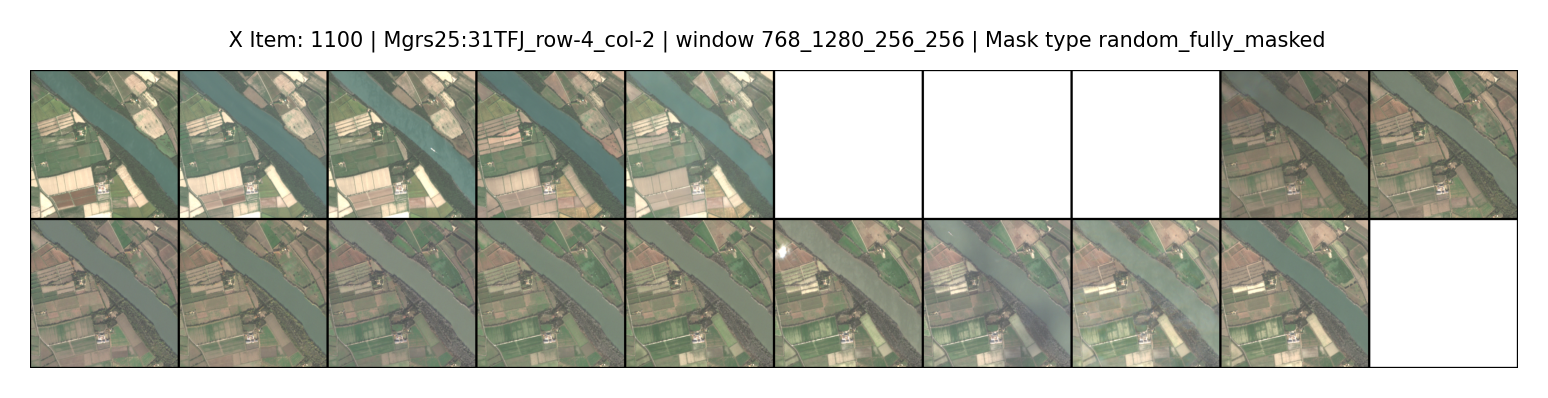

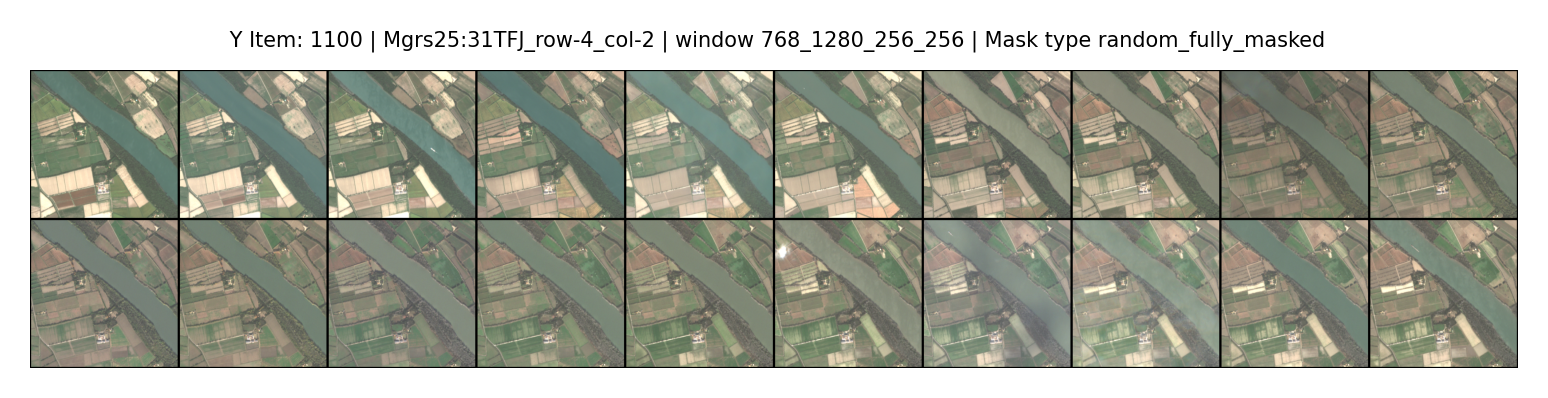

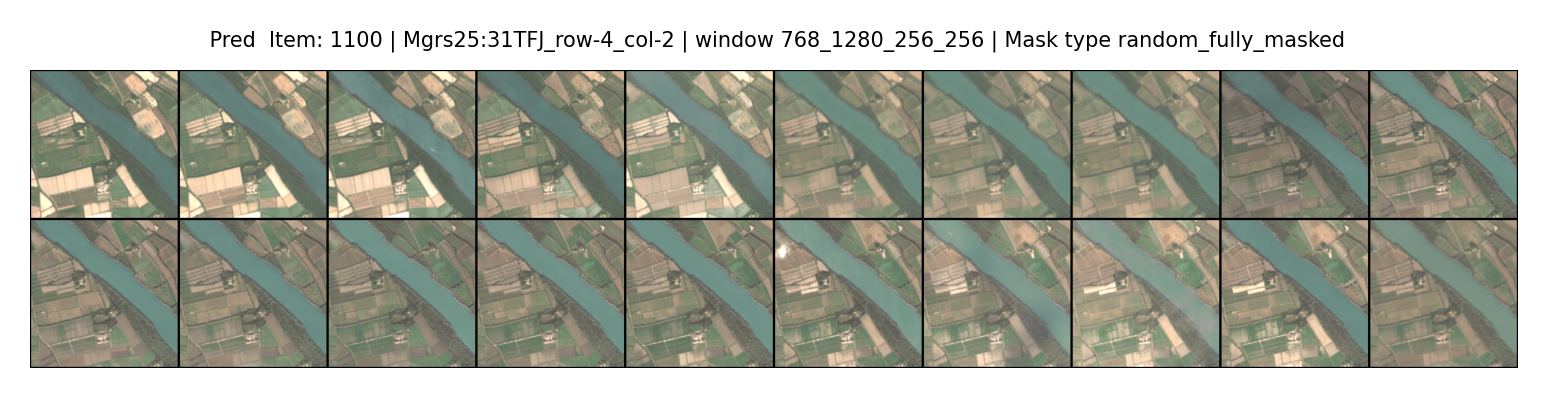

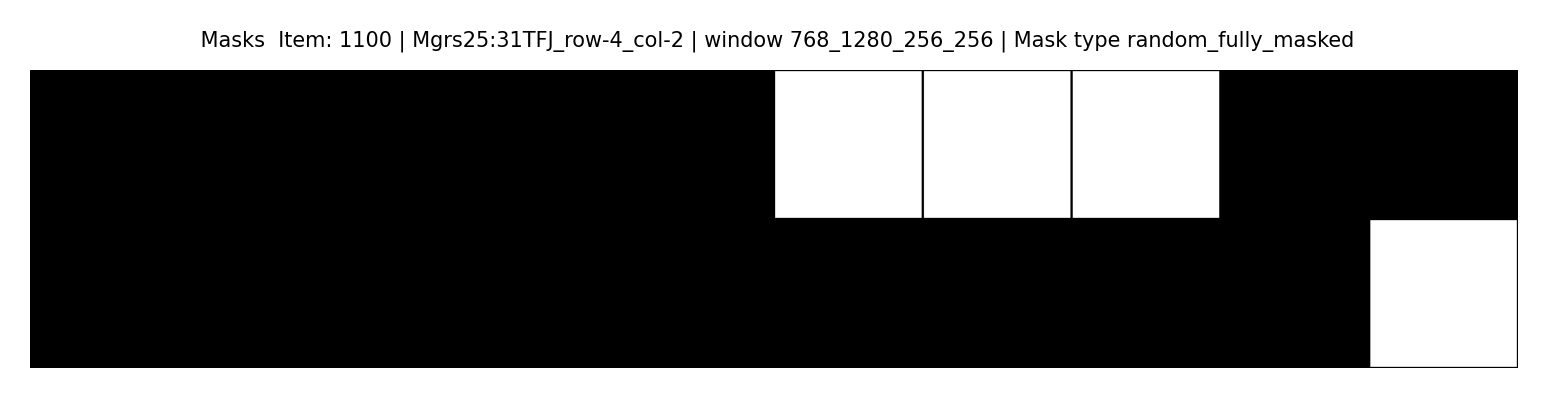

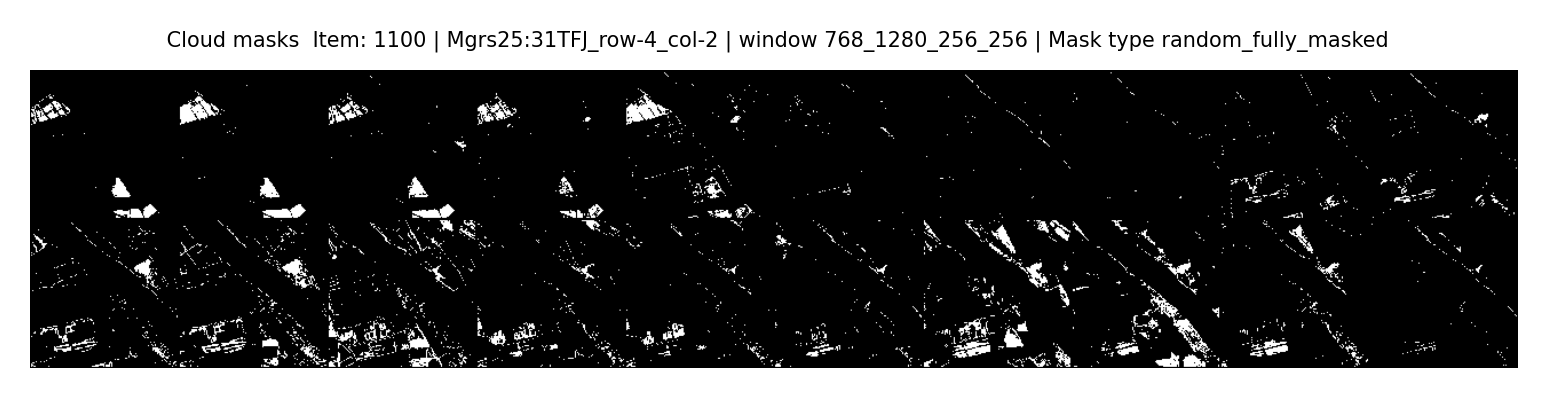

In [13]:
item = 1100
t_start = 0
t_end = 20

sample = dataloader.dataset.__getitem__(item)
batch = sample_to_batch(sample)
batch, y_pred, att = inference_imputation.impute_sample(
    batch=batch,
    return_att=True,
    t_start=t_start,
    t_end=t_end,
)

fig = visutils.sequence2gallery(
    batch['x'][0], 
    indices_rgb=sample['c_index_rgb'], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f" X Item: {item} | Mgrs25:{sample['info']['mgrs25']} | window {sample['info']['window']} | Mask type {config.mask.mask_type}", fontsize=5)

fig = visutils.sequence2gallery(
    batch['y'][0], 
    indices_rgb=sample['c_index_rgb'], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f" Y Item: {item} | Mgrs25:{sample['info']['mgrs25']} | window {sample['info']['window']} | Mask type {config.mask.mask_type}", fontsize=5)

fig = visutils.sequence2gallery(
    y_pred[0], 
    indices_rgb=sample['c_index_rgb'], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f" Pred  Item: {item} | Mgrs25:{sample['info']['mgrs25']} | window {sample['info']['window']} | Mask type {config.mask.mask_type}", fontsize=5)

# Affichage mask pour le training
fig = visutils.sequence2gallery(
    batch['masks'][0], 
    variable='binary_mask',
    indices_rgb=sample['c_index_rgb'], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f" Masks  Item: {item} | Mgrs25:{sample['info']['mgrs25']} | window {sample['info']['window']} | Mask type {config.mask.mask_type}", fontsize=5)

# Afficahge cloud mask d'origine contenant les pixels nuageux que l'on ne va pas considérer
fig = visutils.sequence2gallery(
    batch['cloud_mask'][0],
    variable='binary_mask',
    indices_rgb=sample['c_index_rgb'], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f" Cloud masks  Item: {item} | Mgrs25:{sample['info']['mgrs25']} | window {sample['info']['window']} | Mask type {config.mask.mask_type}", fontsize=5)

plt.show()

In [12]:
# Calcul des métriques
from dataloader_CIRCA.datasets.cr_metrics import CloudRemovalMetrics
from dataloader_CIRCA.datasets.cr_metrics import display_metrics

metrics = ["mae", "mse", "rmse", "psnr", "ssim", "r2", "sam"]
cr_metrics = CloudRemovalMetrics(
        metrics=metrics,
        clean_gt_cloudy_pixels=True,
        eval_occluded_observed=True,
)
metrics_dict = cr_metrics(
    target=batch["y"],
    masks=batch["masks"],
    predicted=y_pred,
    cloud_masks=batch.get("cloud_mask", None),
)

display_metrics(metrics_dict)

              Cloud Reconstruction Metrics              
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Overall ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│    MAE │ 0.0129  │     0.0272      │     0.0066      │
│    MSE │ 0.0005  │     0.0015      │     0.0001      │
│   PSNR │ 32.7635 │     28.1570     │     40.6887     │
│     R2 │ 0.9519  │     0.8450      │     0.9926      │
│   RMSE │ 0.0230  │     0.0391      │     0.0092      │
│    SAM │ 0.0507  │     0.0939      │     0.0315      │
│   SSIM │ 0.9599  │     0.9082      │     0.9821      │
└────────┴─────────┴─────────────────┴─────────────────┘

# Lecture de métriques

In [7]:
import pandas as pd
import json
import os
from pathlib import Path
from dataloader_CIRCA.datasets.cr_metrics import display_metrics

store = Path("/mnt/stores/store-dai/")
folder_metrics = store / "tmp/speillet/metrics"
assert folder_metrics.exists()
files_metrics = {f.parent.name: f for f in folder_metrics.rglob("*.json")}

for name, f in files_metrics.items():
    print("Name: ", name)
    content = json.load(open(f))
    # Suppression des clés sur le MSE
    for x in ["mse", "mse_occluded_input_pixels", "mse_observed_input_pixels"]:
        content.pop(x)
    display_metrics(content)

Name:  random_fully_masked


              Cloud Reconstruction Metrics               
┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Overall  ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│    MAE │ 116.9597 │    573.0428     │     65.0991     │
│   PSNR │ 34.7373  │     24.9644     │     40.6641     │
│     R2 │  0.9371  │     0.1491      │     0.9917      │
│   RMSE │ 236.1876 │    753.7958     │     95.9765     │
│    SAM │  0.0386  │     0.1176      │     0.0290      │
│   SSIM │  0.7760  │     0.4742      │     0.8215      │
└────────┴──────────┴─────────────────┴─────────────────┘

Name:  random_clouds


              Cloud Reconstruction Metrics               
┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Overall  ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│    MAE │ 123.6418 │    332.0188     │     65.1150     │
│   PSNR │ 32.8185  │     26.6282     │     40.6354     │
│     R2 │  0.9363  │     0.7267      │     0.9916      │
│   RMSE │ 258.0339 │    526.4728     │     95.9444     │
│    SAM │  0.0408  │     0.0885      │     0.0290      │
│   SSIM │  0.7600  │     0.6029      │     0.8223      │
└────────┴──────────┴─────────────────┴─────────────────┘

Name:  consecutive_fully_masked


              Cloud Reconstruction Metrics               
┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Overall  ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│    MAE │ 116.9597 │    573.0428     │     65.0990     │
│   PSNR │ 34.7373  │     24.9643     │     40.6641     │
│     R2 │  0.9371  │     0.1491      │     0.9917      │
│   RMSE │ 236.1873 │    753.7958     │     95.9767     │
│    SAM │  0.0386  │     0.1176      │     0.0290      │
│   SSIM │  0.7760  │     0.4742      │     0.8215      │
└────────┴──────────┴─────────────────┴─────────────────┘

In [6]:
display_metrics(content)

              Cloud Reconstruction Metrics               
┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Overall  ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│    MAE │ 116.9597 │    573.0428     │     65.0990     │
│   PSNR │ 34.7373  │     24.9643     │     40.6641     │
│     R2 │  0.9371  │     0.1491      │     0.9917      │
│   RMSE │ 236.1873 │    753.7958     │     95.9767     │
│    SAM │  0.0386  │     0.1176      │     0.0290      │
│   SSIM │  0.7760  │     0.4742      │     0.8215      │
└────────┴──────────┴─────────────────┴─────────────────┘